# RDM partial correlation analysis

Per-layer Spearman partial correlation:
$$\rho(D_{\text{model}},\ D_{\text{cipher B}}\ |\ D_{\text{cipher A}})$$

**Cipher A** (lexical, control): $1 - \cos(\text{emb}(\text{ctx}_i), \text{emb}(\text{ctx}_j))$ via Qwen3-Embedding-0.6B.  
**Cipher B** (pragmatic, target): $|\text{pragrel}_i - \text{pragrel}_j|$ from human ratings (`AV` column).  
**Empirical RDM**: $1 - \cos(h_i^{\ell}, h_j^{\ell})$ from the saved hidden states.  

Restricted to non-NC prompts (cipher A is ill-defined for empty contexts). 95 % CIs from cluster bootstrap over 15 questions; with that few clusters the CIs are borderline-reliable â€” interpret widths as approximate.

**Inputs** (from a single Drive folder):
- `hidden_states_{model}.npz` + `hidden_states_meta_{model}.csv` per model
- `QuestionContext_Scores.csv`

**Outputs** (written to the same folder, suffixed `_rdm`):
- `rdm_results.csv`, `rdm_diagnostics.csv`, `rdm_trajectory.png`, `rdm_marginals.png`

Runtime: ~2â€“5 min total on CPU runtime. No GPU needed.

## 1. Setup â€” install, mount Drive, configure paths

In [1]:
!pip install -q sentence-transformers tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path

# â”€â”€â”€ EDIT THESE TWO PATHS â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Folder containing the hidden_states_*.npz and hidden_states_meta_*.csv files
DATA_DIR = Path('../data/rdm')

# Where to write outputs (created if missing)
OUTPUT_DIR = Path('../results/rdm')
# â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

# Optional: restrict to specific models. Leave as None to process every
# hidden_states_*.npz it finds.
MODELS_FILTER = None   # e.g. ['qwen', 'mistral']

# Cipher-A method: 'sbert' (Qwen3-Embedding-0.6B) or 'tfidf' (char n-grams).
# Use sbert for headline results; tfidf is a no-dependency fallback.
CIPHER_A_METHOD = 'sbert'

N_BOOT = 1000
RANDOM_SEED = 42
POOLING_VARIANTS = ['last_token_hs', 'mean_pool_hs']

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Quick sanity check
print(f'DATA_DIR : {DATA_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')
print()
print('NPZ files found:')
for p in sorted(DATA_DIR.glob('hidden_states_*.npz')):
    print(f'  {p.name}  ({p.stat().st_size / 1e6:.1f} MB)')
print()
SCORES_PATH = Path('../data/human/QuestionContext_Scores.csv')
ctx_path = SCORES_PATH
print(f'Context scores: {ctx_path}  exists={ctx_path.exists()}')

DATA_DIR : data
OUTPUT_DIR: data\rdm_outputs

NPZ files found:
  hidden_states_deepseek.npz  (139.7 MB)
  hidden_states_deepseek_v2_lite.npz  (63.6 MB)
  hidden_states_llama.npz  (149.2 MB)
  hidden_states_llama_base.npz  (145.5 MB)
  hidden_states_mistral.npz  (149.3 MB)
  hidden_states_qwen.npz  (113.4 MB)
  hidden_states_qwen_base.npz  (109.9 MB)

Context scores: data\QuestionContext_Scores.csv  exists=True


## 2. Helpers â€” RDM primitives, partial correlation, bootstrap

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from tqdm import tqdm

MODEL_COLORS = {
    'qwen': '#1976D2',
    'qwen_base':'#000000',
    'deepseek': '#388E3C',
    'mistral': '#F57C00',
    'llama': '#7B1FA2',
    'llama_base':'#cdcdcd',
    'deepseek_v2_lite': '#00897B',
}


def upper_tri(M):
    """Upper-triangular off-diagonal vectorisation."""
    return M[np.triu_indices_from(M, k=1)]


def cosine_rdm(features):
    """1 - cos similarity matrix from (n, d) features."""
    X = features.astype(np.float32)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    X_norm = X / np.maximum(norms, 1e-12)
    cos = X_norm @ X_norm.T
    cos = np.clip(cos, -1.0, 1.0)
    return 1.0 - cos


def partial_spearman(m, b, a):
    """Spearman partial correlation rho(m, b | a).

    Returns (partial, rho_mb, rho_ma, rho_ba). NaN if denominator degenerate.
    """
    rho_mb, _ = spearmanr(m, b)
    rho_ma, _ = spearmanr(m, a)
    rho_ba, _ = spearmanr(b, a)
    if np.isnan(rho_mb) or np.isnan(rho_ma) or np.isnan(rho_ba):
        return np.nan, rho_mb, rho_ma, rho_ba
    denom = np.sqrt(max(1 - rho_ma**2, 0.0) * max(1 - rho_ba**2, 0.0))
    if denom < 1e-12:
        return np.nan, rho_mb, rho_ma, rho_ba
    return (rho_mb - rho_ma * rho_ba) / denom, rho_mb, rho_ma, rho_ba


def cluster_bootstrap_partial_corr(features, rdm_a, rdm_b,
                                    question_ids, n_boot=N_BOOT,
                                    seed=RANDOM_SEED):
    """Cluster bootstrap over questions for rho(D_model, D_B | D_A)."""
    rng = np.random.default_rng(seed)
    unique_qs = np.unique(question_ids)
    n_q = len(unique_qs)

    rdm_m_full = cosine_rdm(features)
    point, rho_mb, rho_ma, rho_ba = partial_spearman(
        upper_tri(rdm_m_full), upper_tri(rdm_b), upper_tri(rdm_a)
    )

    q_to_idx = {q: np.where(question_ids == q)[0] for q in unique_qs}
    boots = np.full(n_boot, np.nan, dtype=np.float32)
    for bi in range(n_boot):
        sampled_qs = rng.choice(unique_qs, size=n_q, replace=True)
        idx = np.concatenate([q_to_idx[q] for q in sampled_qs])
        feats_sub = features[idx]
        rdm_m_sub = cosine_rdm(feats_sub)
        rdm_a_sub = rdm_a[np.ix_(idx, idx)]
        rdm_b_sub = rdm_b[np.ix_(idx, idx)]
        partial_b, _, _, _ = partial_spearman(
            upper_tri(rdm_m_sub), upper_tri(rdm_b_sub), upper_tri(rdm_a_sub)
        )
        boots[bi] = partial_b

    valid = boots[~np.isnan(boots)]
    if len(valid) < 50:
        return dict(point=point, lo=np.nan, hi=np.nan,
                    rho_mb=rho_mb, rho_ma=rho_ma, rho_ba=rho_ba,
                    n_boot_valid=int(len(valid)))
    lo, hi = np.percentile(valid, [2.5, 97.5])
    return dict(point=point, lo=float(lo), hi=float(hi),
                rho_mb=rho_mb, rho_ma=rho_ma, rho_ba=rho_ba,
                n_boot_valid=int(len(valid)))

print('Helpers defined.')

Helpers defined.


## 3. Build cipher-A and cipher-B theoretical RDMs

Loads predictors once, builds two theoretical RDMs that all model analyses share.

In [4]:
def _embed_sbert(question, context):
    """Qwen3-Embedding-0.6B, CPU. Returns per-prompt cos(Q, C) scalars."""
    from sentence_transformers import SentenceTransformer
    print('  Loading SBERT (Qwen/Qwen3-Embedding-0.6B, CPU)...')
    sbert = SentenceTransformer('Qwen/Qwen3-Embedding-0.6B', device='cpu')
    q_embs = sbert.encode(question, convert_to_numpy=True, show_progress_bar=False)
    c_embs = sbert.encode(context,  convert_to_numpy=True, show_progress_bar=False)
    q_embs /= (np.linalg.norm(q_embs, axis=1, keepdims=True) + 1e-12)
    c_embs /= (np.linalg.norm(c_embs, axis=1, keepdims=True) + 1e-12)
    return np.sum(q_embs * c_embs, axis=1)  # element-wise cos per prompt


def _embed_tfidf(question, context):
    """Char n-gram TF-IDF. Vocab fit on the combined Q+C corpus so vectors are comparable."""
    from sklearn.feature_extraction.text import TfidfVectorizer
    vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=1)
    vec.fit(list(question) + list(context))
    Q = vec.transform(question).toarray()
    C = vec.transform(context).toarray()
    Q /= (np.linalg.norm(Q, axis=1, keepdims=True) + 1e-12)
    C /= (np.linalg.norm(C, axis=1, keepdims=True) + 1e-12)
    return np.sum(Q * C, axis=1)
    
def build_cipher_b_rdm(pragrel):
    return np.abs(pragrel[:, None] - pragrel[None, :]).astype(np.float32)

def build_cipher_a_rdm(question, context, method='sbert'):
    sims = (_embed_sbert(question, context) if method == 'sbert'
            else _embed_tfidf(question, context))
    return np.abs(sims[:, None] - sims[None, :]).astype(np.float32), sims

def load_predictors(context_scores_path, contexts_meta_df):
    meta = contexts_meta_df.copy()
    meta['condition'] = (
        meta['condition'].astype(str).str.strip().str.lower()
        .str.replace(r'\s+', '_', regex=True)
    )
    meta['context'] = meta['context'].fillna('').astype(str).str.strip()
    if 'question_id' not in meta.columns:
        meta['question_id'] = (meta['prompt_id'] - 1) // 4 + 1

    scores = pd.read_csv(context_scores_path).dropna(subset=['Num', 'AV'])
    scores['prompt_id'] = scores['Num'].astype(int)
    scores = scores[['prompt_id', 'AV']].rename(columns={'AV': 'pragmatic_relevance'})

    out = (meta.merge(scores, on='prompt_id', how='inner')
                .query('condition != "no_context"')
                .sort_values('prompt_id')
                .reset_index(drop=True))
    return out[['prompt_id', 'question_id', 'condition', 'question', 'context',
            'pragmatic_relevance']]

# Use any one metadata CSV as the canonical context source â€” they're identical
# at the prompt level across model runs.
npz_files = sorted(DATA_DIR.glob('hidden_states_*.npz'))
if MODELS_FILTER:
    npz_files = [f for f in npz_files
                 if f.stem.replace('hidden_states_', '') in MODELS_FILTER]
assert npz_files, f'No hidden_states_*.npz in {DATA_DIR}'
first_label = npz_files[0].stem.replace('hidden_states_', '')
first_meta = DATA_DIR / f'hidden_states_meta_{first_label}.csv'
meta_canonical = pd.read_csv(first_meta)

pred = load_predictors(SCORES_PATH, meta_canonical)
print(f'Non-NC rated prompts: {len(pred)}')
print(f'Conditions: {pred["condition"].value_counts().to_dict()}')
print(f'Questions:  {pred["question_id"].nunique()} unique')

print('\nBuilding theoretical RDMs...')
rdm_a, sims_a = build_cipher_a_rdm(
    pred['question'].tolist(),   # add this â€” load_predictors must include it
    pred['context'].tolist(),
    method=CIPHER_A_METHOD,
)
rdm_b = build_cipher_b_rdm(pred['pragmatic_relevance'].values.astype(np.float32))
rho_ab, _ = spearmanr(upper_tri(rdm_a), upper_tri(rdm_b))
print(f'  RDM_A shape={rdm_a.shape}  mean off-diag={upper_tri(rdm_a).mean():.4f}')
print(f'  RDM_B shape={rdm_b.shape}  mean off-diag={upper_tri(rdm_b).mean():.4f}')
print(f'  Spearman rho(RDM_A, RDM_B) = {rho_ab:+.4f}'
      f'   (low |rho| means cipher A and B are nearly independent â€” good for partial corr)')

Non-NC rated prompts: 45
Conditions: {'direct_information': 15, 'implicature_information': 15, 'stochastic_information': 15}
Questions:  15 unique

Building theoretical RDMs...
  Loading SBERT (Qwen/Qwen3-Embedding-0.6B, CPU)...
  RDM_A shape=(45, 45)  mean off-diag=0.1164
  RDM_B shape=(45, 45)  mean off-diag=1.5170
  Spearman rho(RDM_A, RDM_B) = +0.4205   (low |rho| means cipher A and B are nearly independent â€” good for partial corr)


## 4. Per-model analysis â€” iterate over (model, pooling, layer)

In [5]:
def analyze_model(npz_path, meta_path, pred, rdm_a, rdm_b, n_boot, seed):
    """RDM analysis for one model. Returns (results_df, diagnostics_dict)."""
    model_label = npz_path.stem.replace('hidden_states_', '')

    npz = np.load(npz_path)
    meta = pd.read_csv(meta_path)

    # Align meta to predictor table by prompt_id
    valid_pids = pred['prompt_id'].values
    meta_idx_map = {int(pid): i for i, pid in enumerate(meta['prompt_id'].values)}
    keep_idx_in_npz, keep_idx_in_pred = [], []
    for i, pid in enumerate(valid_pids):
        if int(pid) in meta_idx_map:
            keep_idx_in_npz.append(meta_idx_map[int(pid)])
            keep_idx_in_pred.append(i)
    keep_idx_in_npz = np.array(keep_idx_in_npz)
    keep_idx_in_pred = np.array(keep_idx_in_pred)

    rdm_a_sub = rdm_a[np.ix_(keep_idx_in_pred, keep_idx_in_pred)]
    rdm_b_sub = rdm_b[np.ix_(keep_idx_in_pred, keep_idx_in_pred)]
    question_ids = pred['question_id'].values[keep_idx_in_pred]

    n_prompts = len(keep_idx_in_npz)
    nan_mask = npz['nan_mask'][keep_idx_in_npz]
    n_layers = int(npz['last_token_hs'].shape[1])

    rho_ab_local, _ = spearmanr(upper_tri(rdm_a_sub), upper_tri(rdm_b_sub))
    diagnostics = dict(
        model=model_label,
        n_prompts_in_npz=int(npz['last_token_hs'].shape[0]),
        n_prompts_used=int(n_prompts),
        n_layers=n_layers,
        rho_AB_theoretical=float(rho_ab_local),
        nan_affected_layers=int((nan_mask.sum(axis=0) > 0).sum()),
    )

    rows = []
    for pooling in POOLING_VARIANTS:
        feats_kept = npz[pooling][keep_idx_in_npz]
        for layer in tqdm(range(n_layers),
                          desc=f'  {model_label}/{pooling}', leave=False):
            n_nan = int(nan_mask[:, layer].sum())
            if n_nan > 0.5 * n_prompts:
                rows.append(dict(
                    model=model_label, pooling=pooling, layer=layer,
                    n_prompts=n_prompts, n_nan_at_layer=n_nan, skipped=True,
                    point=np.nan, ci_lo=np.nan, ci_hi=np.nan,
                    rho_mb=np.nan, rho_ma=np.nan, rho_ba=np.nan,
                    n_boot_valid=0,
                ))
                continue
            features = feats_kept[:, layer, :].astype(np.float32)
            res = cluster_bootstrap_partial_corr(
                features, rdm_a_sub, rdm_b_sub, question_ids,
                n_boot=n_boot, seed=seed,
            )
            rows.append(dict(
                model=model_label, pooling=pooling, layer=layer,
                n_prompts=n_prompts, n_nan_at_layer=n_nan, skipped=False,
                point=res['point'], ci_lo=res['lo'], ci_hi=res['hi'],
                rho_mb=res['rho_mb'], rho_ma=res['rho_ma'], rho_ba=res['rho_ba'],
                n_boot_valid=res['n_boot_valid'],
            ))
    return pd.DataFrame(rows), diagnostics


In [6]:
# Run per-model RDM partial correlation, building results_df and diag_df.
all_results, all_diag = [], []
for npz_path in npz_files:
    label = npz_path.stem.replace('hidden_states_', '')
    meta_path = DATA_DIR / f'hidden_states_meta_{label}.csv'
    if not meta_path.exists():
        print(f'  Skipping {label}: missing metadata CSV')
        continue
    print(f'\nModel: {label}')
    res, diag = analyze_model(npz_path, meta_path, pred, rdm_a, rdm_b,
                              N_BOOT, RANDOM_SEED)
    all_results.append(res)
    all_diag.append(diag)
    print(f'  n_used={diag["n_prompts_used"]}, n_layers={diag["n_layers"]}, '
          f'NaN-affected layers={diag["nan_affected_layers"]}')

results_df = pd.concat(all_results, ignore_index=True)
diag_df = pd.DataFrame(all_diag)
results_df.to_csv(OUTPUT_DIR / 'rdm_results.csv', index=False)
diag_df.to_csv(OUTPUT_DIR / 'rdm_diagnostics.csv', index=False)
print(f'\nResults  -> {OUTPUT_DIR / "rdm_results.csv"}')
print(f'Diagnostics -> {OUTPUT_DIR / "rdm_diagnostics.csv"}')
diag_df



Model: deepseek


  n_used=45, n_layers=31, NaN-affected layers=0

Model: deepseek_v2_lite


  n_used=45, n_layers=28, NaN-affected layers=0

Model: llama


  n_used=45, n_layers=33, NaN-affected layers=0

Model: llama_base


  n_used=45, n_layers=33, NaN-affected layers=0

Model: mistral


  n_used=45, n_layers=33, NaN-affected layers=0

Model: qwen


  n_used=45, n_layers=29, NaN-affected layers=1

Model: qwen_base


  n_used=45, n_layers=29, NaN-affected layers=1

Results  -> data\rdm_outputs\rdm_results.csv
Diagnostics -> data\rdm_outputs\rdm_diagnostics.csv


,model,n_prompts_in_npz,n_prompts_used,n_layers,rho_AB_theoretical,nan_affected_layers
0,deepseek,60,45,31,0.420489,0
1,deepseek_v2_lite,60,45,28,0.420489,0
2,llama,60,45,33,0.420489,0
3,llama_base,60,45,33,0.420489,0
4,mistral,60,45,33,0.420489,0
5,qwen,60,45,29,0.420489,1
6,qwen_base,60,45,29,0.420489,1


## 5. Rogue-dimension diagnostic
Following Timkey & van Schijndel (2021), check whether cosine similarity at each (model, layer) is dominated by 1-3 outlier dimensions. If so, partial correlations there primarily reflect those dimensions rather than the full representation.

In [7]:
#DIAGNOSTICS
# â”€â”€â”€ DIAGNOSTIC CELL 1: rogue dimensions â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
#
# Implements Timkey & van Schijndel (2021) "All Bark and No Bite" diagnostic
# for whether cosine similarity in each (model, layer) is dominated by a
# small number of outlier dimensions.
#
# Two metrics per (model, pooling, layer):
#   (a) Anisotropy   = mean off-diagonal cosine similarity over all 45
#                      non-NC prompts. Values near 1 mean all prompts look
#                      similar to all other prompts in this layer.
#   (b) Top-k cosine contribution = fraction of the anisotropy that comes
#                      from the top 1, 3, 5 dimensions (ranked by |CC_d|).
#
# Decision rule (from the paper):
#   - Top-1 contribution > 30%  ->  layer is rogue-dominated; partial
#                                   correlations there mainly reflect 1
#                                   outlier dimension. Standardise.
#   - Top-1 contribution < 10%  ->  cosine is informative as-is.
#   - In between                ->  borderline; standardisation as
#                                   robustness check is sensible but the
#                                   raw result probably stands.

import numpy as np
import pandas as pd
from pathlib import Path

# Reuse already-computed kept-prompt indices from the analysis cell? No â€”
# this cell stands alone for portability. Recompute the prompt filter.
def _filter_prompts(npz, meta, pred):
    valid_pids = pred['prompt_id'].values
    meta_idx_map = {int(pid): i for i, pid in enumerate(meta['prompt_id'].values)}
    keep = [meta_idx_map[int(p)] for p in valid_pids if int(p) in meta_idx_map]
    return np.array(keep)


def cosine_contribution_per_dim(features):
    """Per-dim contribution to mean off-diagonal cosine. Sums to anisotropy.

    For an L2-normalised set X (n, d), the contribution of dimension d to
    average upper-triangular cosine is:
        CC[d] = (sum_i X[i,d])^2 - sum_i X[i,d]^2  /  (2 * n_pairs)
    """
    X = features.astype(np.float32)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    Xn = X / np.maximum(norms, 1e-12)
    n = Xn.shape[0]
    n_pairs = n * (n - 1) // 2
    s = Xn.sum(axis=0)
    s2 = (Xn ** 2).sum(axis=0)
    return (s ** 2 - s2) / (2 * n_pairs)


def diagnostic_for_npz(npz_path, meta_path, pred, poolings=POOLING_VARIANTS):
    npz = np.load(npz_path)
    meta = pd.read_csv(meta_path)
    keep = _filter_prompts(npz, meta, pred)
    nan_mask = npz['nan_mask'][keep]

    rows = []
    for pooling in poolings:
        feats_kept = npz[pooling][keep]    # (n_prompts, n_layers, hidden_dim)
        n_layers = feats_kept.shape[1]
        for layer in range(n_layers):
            n_nan = int(nan_mask[:, layer].sum())
            if n_nan > 0.5 * len(keep):
                rows.append(dict(model=npz_path.stem.replace('hidden_states_', ''),
                                 pooling=pooling, layer=layer,
                                 anisotropy=np.nan, top1=np.nan, top3=np.nan,
                                 top5=np.nan, skipped=True))
                continue
            cc = cosine_contribution_per_dim(feats_kept[:, layer, :])
            anisotropy = float(cc.sum())
            ranked = np.sort(np.abs(cc))[::-1]
            # Use signed cc summed in rank order â€” paper defines the
            # contribution as signed. Take the abs-sorted indices but sum the
            # signed values (convention from paper Section 3.1).
            sorted_idx = np.argsort(np.abs(cc))[::-1]
            top1 = float(cc[sorted_idx[:1]].sum())
            top3 = float(cc[sorted_idx[:3]].sum())
            top5 = float(cc[sorted_idx[:5]].sum())
            rows.append(dict(
                model=npz_path.stem.replace('hidden_states_', ''),
                pooling=pooling, layer=layer,
                anisotropy=anisotropy,
                top1=top1, top3=top3, top5=top5,
                top1_frac=top1 / anisotropy if abs(anisotropy) > 1e-6 else np.nan,
                top3_frac=top3 / anisotropy if abs(anisotropy) > 1e-6 else np.nan,
                top5_frac=top5 / anisotropy if abs(anisotropy) > 1e-6 else np.nan,
                skipped=False,
            ))
    return pd.DataFrame(rows)


print('Computing rogue-dimension diagnostic per (model, pooling, layer)...')
diag_rows = []
for npz_path in npz_files:
    label = npz_path.stem.replace('hidden_states_', '')
    meta_path = DATA_DIR / f'hidden_states_meta_{label}.csv'
    if not meta_path.exists():
        continue
    print(f'  {label}...')
    diag_rows.append(diagnostic_for_npz(npz_path, meta_path, pred))
rogue_df = pd.concat(diag_rows, ignore_index=True)
rogue_df.to_csv(OUTPUT_DIR / 'rogue_dim_diagnostic.csv', index=False)
print(f'Saved -> {OUTPUT_DIR / "rogue_dim_diagnostic.csv"}')

# Summary at peak partial-correlation layer for each model (last_token_hs)
print('\nROGUE-DIM SUMMARY at peak-partial layer (last_token_hs):')
print(f'{"model":<20} {"L":>3}  {"anisotropy":>10}  {"top1%":>6}  {"top3%":>6}  {"top5%":>6}  verdict')
for model in sorted(rogue_df['model'].unique()):
    # Get peak layer from results_df (already computed earlier in the notebook)
    d_res = results_df[(results_df['model'] == model) &
                       (results_df['pooling'] == 'last_token_hs') &
                       (~results_df['skipped'])]
    if d_res.empty:
        continue
    peak_layer = int(d_res.loc[d_res['point'].idxmax(), 'layer'])
    rogue = rogue_df[(rogue_df['model'] == model) &
                     (rogue_df['pooling'] == 'last_token_hs') &
                     (rogue_df['layer'] == peak_layer)].iloc[0]
    t1 = rogue['top1_frac']
    verdict = ('rogue-dominated'    if t1 > 0.30 else
               'borderline'         if t1 > 0.10 else
               'broadly-distributed')
    print(f'  {model:<18} {peak_layer:>3}  {rogue["anisotropy"]:>+10.4f}  '
          f'{t1*100:>5.1f}%  {rogue["top3_frac"]*100:>5.1f}%  '
          f'{rogue["top5_frac"]*100:>5.1f}%  {verdict}')

# Also report across all layers â€” flag any that exceed the rogue threshold
print('\nLAYERS with top-1 dim > 30% of anisotropy (last_token_hs):')
for model in sorted(rogue_df['model'].unique()):
    d = rogue_df[(rogue_df['model'] == model) &
                 (rogue_df['pooling'] == 'last_token_hs') &
                 (~rogue_df['skipped'])]
    bad_layers = d[d['top1_frac'] > 0.30]['layer'].tolist()
    print(f'  {model:<20} {len(bad_layers)} layers: {bad_layers if len(bad_layers) <= 10 else f"{bad_layers[:5]} ... {bad_layers[-5:]}"}')

Computing rogue-dimension diagnostic per (model, pooling, layer)...
  deepseek...
  deepseek_v2_lite...
  llama...
  llama_base...
  mistral...
  qwen...
  qwen_base...
Saved -> data\rdm_outputs\rogue_dim_diagnostic.csv

ROGUE-DIM SUMMARY at peak-partial layer (last_token_hs):
model                  L  anisotropy   top1%   top3%   top5%  verdict
  deepseek            16     +0.8724   10.4%   18.5%   22.7%  borderline
  deepseek_v2_lite     3     +0.9956   37.5%   63.0%   70.2%  rogue-dominated
  llama               15     +0.8715   24.3%   27.4%   29.6%  borderline
  llama_base          32     +0.7495    5.4%   12.2%   18.2%  broadly-distributed
  mistral             16     +0.8659    2.4%    5.4%    7.1%  broadly-distributed
  qwen                19     +0.9411   27.9%   54.0%   59.7%  borderline
  qwen_base           18     +0.8383   25.1%   43.8%   47.1%  borderline

LAYERS with top-1 dim > 30% of anisotropy (last_token_hs):
  deepseek             6 layers: [1, 25, 26, 27, 28, 29]
 

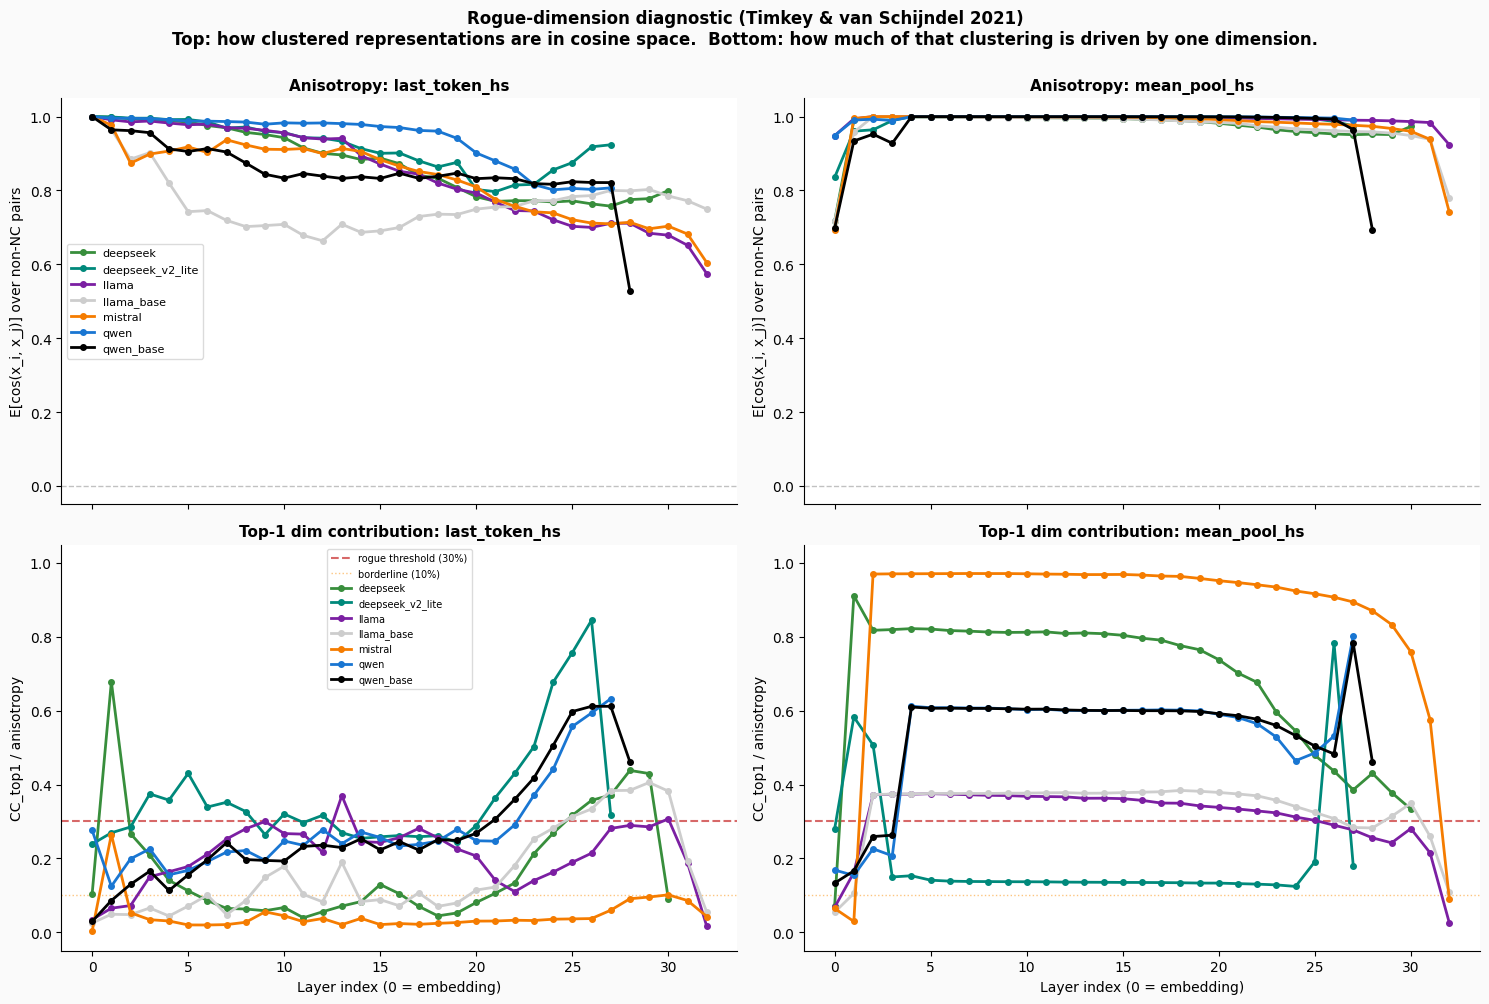

Plot -> data\rdm_outputs\rogue_dim_diagnostic.png


In [8]:
#DIAGNOSTIC 2
# â”€â”€â”€ DIAGNOSTIC CELL 2: visualisation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
#
# Two panels per pooling variant:
#   (a) Anisotropy by layer â€” how clustered representations are in cosine space.
#       High values (>0.5) mean any two prompts look similar; low values
#       mean the space is well-spread.
#   (b) Top-1 dimension contribution by layer â€” what fraction of that
#       anisotropy comes from a single dimension. A value of 0.3 means
#       30% of the cosine signal at this layer is coming from one number
#       in a 3000+-dimensional vector. Anything above ~0.3 means standardisation
#       will materially change the RDM. The 30% threshold is shown as a dashed line.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
fig.patch.set_facecolor('#FAFAFA')

for col, pooling in enumerate(POOLING_VARIANTS):
    sub = rogue_df[(rogue_df['pooling'] == pooling) & (~rogue_df['skipped'])]

    # Top row: anisotropy
    ax = axes[0, col]
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.axhline(0, color='#999', lw=1, ls='--', alpha=0.6)
    for model in sorted(sub['model'].unique()):
        d = sub[sub['model'] == model].sort_values('layer')
        color = MODEL_COLORS.get(model, '#666')
        ax.plot(d['layer'], d['anisotropy'], color=color, lw=2,
                marker='o', markersize=4, label=model)
    ax.set_title(f'Anisotropy: {pooling}', fontsize=11, fontweight='bold')
    ax.set_ylabel('E[cos(x_i, x_j)] over non-NC pairs', fontsize=10)
    if col == 0:
        ax.legend(fontsize=8, loc='best', framealpha=0.7)

    # Bottom row: top-1 dimension fraction
    ax = axes[1, col]
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.axhline(0.30, color='#C62828', lw=1.5, ls='--', alpha=0.7,
               label='rogue threshold (30%)')
    ax.axhline(0.10, color='#FB8C00', lw=1, ls=':', alpha=0.5,
               label='borderline (10%)')
    for model in sorted(sub['model'].unique()):
        d = sub[sub['model'] == model].sort_values('layer')
        color = MODEL_COLORS.get(model, '#666')
        ax.plot(d['layer'], d['top1_frac'], color=color, lw=2,
                marker='o', markersize=4, label=model)
    ax.set_title(f'Top-1 dim contribution: {pooling}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Layer index (0 = embedding)', fontsize=10)
    ax.set_ylabel('CC_top1 / anisotropy', fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    if col == 0:
        ax.legend(fontsize=7, loc='best', framealpha=0.7)

fig.suptitle(
    'Rogue-dimension diagnostic (Timkey & van Schijndel 2021)\n'
    'Top: how clustered representations are in cosine space.  '
    'Bottom: how much of that clustering is driven by one dimension.',
    fontsize=12, fontweight='bold', y=1.00,
)
plt.tight_layout()
out = OUTPUT_DIR / 'rogue_dim_diagnostic.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot -> {out}')

## 6. Standardised analysis
Re-run the partial correlation pipeline after per-dimension z-scoring across the 45 prompts at each layer. Compare with the raw results to see how much the rogue dimensions were distorting the cosine measurements.

In [9]:
#ALT CELL 3

# â”€â”€â”€ DIAGNOSTIC CELL 3: standardised analysis â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
#
# Re-runs the analysis after per-dimension standardisation across prompts at
# each layer, following Timkey & van Schijndel (2021).
#
# For each (model, layer, pooling) the features become:
#     z[i, d] = (x[i, d] - mean_d) / std_d
# where mean_d and std_d are computed across the 45 non-NC prompts at that
# specific layer. Cosine RDM, partial correlation, and bootstrap downstream
# are unchanged.
#
# The diagnostic above showed:
#   - DS-V2-Lite: rogue-dominated (top-1 = 37.5%) â€” the null result there
#     is unsafe without this control.
#   - Qwen, LLaMA, DeepSeek: borderline (10â€“28%) â€” should change somewhat.
#   - Mistral: broadly distributed (2.4%) â€” should change very little
#     (sanity check that standardisation isn't destroying real signal).

import numpy as np
import pandas as pd
from tqdm import tqdm


def standardise_per_layer(features, axis_prompts=0, eps=1e-6):
    """Per-dim z-score across prompts.

    features : (n_prompts, hidden_dim)
    Returns standardised features same shape.
    Dimensions with std < eps become zero (constant across prompts).
    """
    mu = features.mean(axis=axis_prompts, keepdims=True)
    sigma = features.std(axis=axis_prompts, keepdims=True)
    sigma = np.where(sigma < eps, 1.0, sigma)
    return (features - mu) / sigma


def analyze_model_standardised(npz_path, meta_path, pred,
                                rdm_a, rdm_b, n_boot, seed):
    """Same pipeline as analyze_model but standardises features per layer."""
    model_label = npz_path.stem.replace('hidden_states_', '')
    npz = np.load(npz_path)
    meta = pd.read_csv(meta_path)

    valid_pids = pred['prompt_id'].values
    meta_idx_map = {int(pid): i for i, pid in enumerate(meta['prompt_id'].values)}
    keep_npz, keep_pred = [], []
    for i, pid in enumerate(valid_pids):
        if int(pid) in meta_idx_map:
            keep_npz.append(meta_idx_map[int(pid)])
            keep_pred.append(i)
    keep_npz = np.array(keep_npz)
    keep_pred = np.array(keep_pred)

    rdm_a_sub = rdm_a[np.ix_(keep_pred, keep_pred)]
    rdm_b_sub = rdm_b[np.ix_(keep_pred, keep_pred)]
    question_ids = pred['question_id'].values[keep_pred]
    nan_mask = npz['nan_mask'][keep_npz]
    n_layers = int(npz['last_token_hs'].shape[1])
    n_prompts = len(keep_npz)

    rows = []
    for pooling in POOLING_VARIANTS:
        feats_kept = npz[pooling][keep_npz]
        for layer in tqdm(range(n_layers),
                          desc=f'  std/{model_label}/{pooling}',
                          leave=False):
            n_nan = int(nan_mask[:, layer].sum())
            if n_nan > 0.5 * n_prompts:
                rows.append(dict(
                    model=model_label, pooling=pooling, layer=layer,
                    standardised=True, skipped=True,
                    point=np.nan, ci_lo=np.nan, ci_hi=np.nan,
                    rho_mb=np.nan, rho_ma=np.nan, rho_ba=np.nan,
                    n_boot_valid=0,
                ))
                continue
            features_raw = feats_kept[:, layer, :].astype(np.float32)
            features = standardise_per_layer(features_raw)
            res = cluster_bootstrap_partial_corr(
                features, rdm_a_sub, rdm_b_sub, question_ids,
                n_boot=n_boot, seed=seed,
            )
            rows.append(dict(
                model=model_label, pooling=pooling, layer=layer,
                standardised=True, skipped=False,
                point=res['point'], ci_lo=res['lo'], ci_hi=res['hi'],
                rho_mb=res['rho_mb'], rho_ma=res['rho_ma'], rho_ba=res['rho_ba'],
                n_boot_valid=res['n_boot_valid'],
            ))
    return pd.DataFrame(rows)


print('Re-running with per-layer standardisation...')
std_results = []
for npz_path in npz_files:
    label = npz_path.stem.replace('hidden_states_', '')
    meta_path = DATA_DIR / f'hidden_states_meta_{label}.csv'
    if not meta_path.exists():
        continue
    print(f'  {label}...')
    res = analyze_model_standardised(
        npz_path, meta_path, pred, rdm_a, rdm_b, N_BOOT, RANDOM_SEED,
    )
    std_results.append(res)

results_std_df = pd.concat(std_results, ignore_index=True)
results_std_df.to_csv(OUTPUT_DIR / 'rdm_results_standardised.csv', index=False)
print(f'\nStandardised results -> {OUTPUT_DIR / "rdm_results_standardised.csv"}')

# â”€â”€ Side-by-side comparison â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print('\n' + '=' * 78)
print('PEAK PARTIAL: raw vs standardised (last_token_hs)')
print('=' * 78)
print(f'{"model":<20} {"L_raw":>5} {"raw":>10} {"L_std":>5} {"std":>10}  Î”')
for model in sorted(results_df['model'].unique()):
    raw = results_df[(results_df['model'] == model) &
                      (results_df['pooling'] == 'last_token_hs') &
                      (~results_df['skipped'])]
    std = results_std_df[(results_std_df['model'] == model) &
                          (results_std_df['pooling'] == 'last_token_hs') &
                          (~results_std_df['skipped'])]
    if raw.empty or std.empty:
        continue
    r_best = raw.loc[raw['point'].idxmax()]
    s_best = std.loc[std['point'].idxmax()]
    delta = s_best['point'] - r_best['point']
    print(f'  {model:<18} {int(r_best["layer"]):>5} {r_best["point"]:>+10.3f}  '
          f'{int(s_best["layer"]):>5} {s_best["point"]:>+10.3f}  '
          f'{delta:>+.3f}')


Re-running with per-layer standardisation...
  deepseek...


  deepseek_v2_lite...


  llama...


  llama_base...


  mistral...


  qwen...


  qwen_base...



Standardised results -> data\rdm_outputs\rdm_results_standardised.csv

PEAK PARTIAL: raw vs standardised (last_token_hs)
model                L_raw        raw L_std        std  Î”
  deepseek              16     +0.244     15     +0.289  +0.045
  deepseek_v2_lite       3     +0.073     12     +0.179  +0.107
  llama                 15     +0.385     15     +0.400  +0.015
  llama_base            32     +0.120     32     +0.197  +0.076
  mistral               16     +0.359     16     +0.404  +0.045
  qwen                  19     +0.472     19     +0.489  +0.018
  qwen_base             18     +0.223     16     +0.300  +0.077


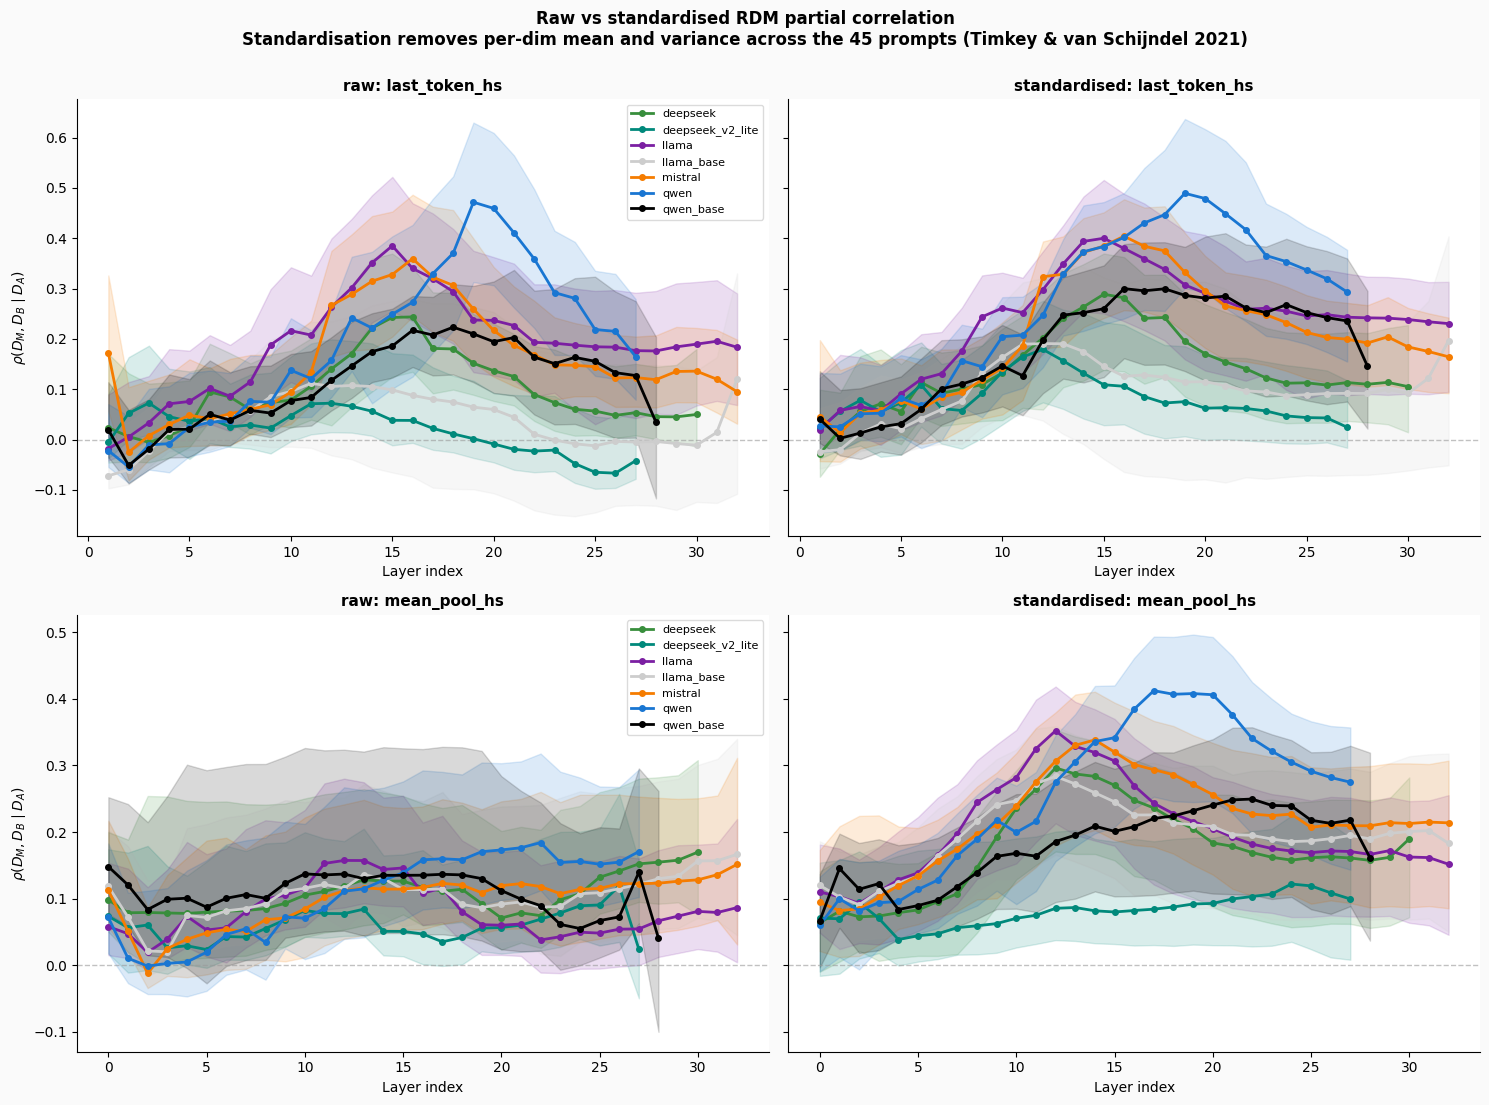

Plot -> data\rdm_outputs\rdm_trajectory_raw_vs_std.png


In [10]:
#ALT PLOT
# â”€â”€â”€ DIAGNOSTIC CELL 4: side-by-side comparison plot â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
#
# Two-panel figure per pooling: raw partial correlation by layer (left),
# standardised partial correlation by layer (right). Shading is 95 % CI.
#
# What to look for:
#   - DS-V2-Lite: should be the most-changed model. If it lifts off zero
#     under standardisation, the rogue dimensions were masking signal. If
#     it stays at zero, the null is robust.
#   - Mistral: should be near-identical raw vs standardised â€” it had no
#     rogue-dimension problem to begin with. If it changes a lot,
#     something is wrong.
#   - Late layers across all models: if the late-layer decay disappears
#     under standardisation, the decay was a rogue-dim artefact, not a
#     genuine washing-out of pragmatic structure near the output.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharey='row')
fig.patch.set_facecolor('#FAFAFA')

for row, pooling in enumerate(POOLING_VARIANTS):
    for col, (df, label) in enumerate([(results_df, 'raw'),
                                         (results_std_df, 'standardised')]):
        ax = axes[row, col]
        ax.set_facecolor('white')
        ax.spines[['top', 'right']].set_visible(False)
        ax.axhline(0, color='#999', lw=1, ls='--', alpha=0.6)

        sub = df[(df['pooling'] == pooling) & (~df['skipped'])]
        for model in sorted(sub['model'].unique()):
            d = sub[sub['model'] == model].sort_values('layer')
            if d.empty:
                continue
            color = MODEL_COLORS.get(model, '#666')
            ax.plot(d['layer'], d['point'], color=color, lw=2,
                    marker='o', markersize=4, label=model)
            ax.fill_between(d['layer'], d['ci_lo'], d['ci_hi'],
                             color=color, alpha=0.15)

        title = f'{label}: {pooling}'
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Layer index', fontsize=10)
        if col == 0:
            ax.set_ylabel(r'$\rho(D_M, D_B \mid D_A)$', fontsize=10)
            ax.legend(fontsize=8, loc='best', framealpha=0.7)

fig.suptitle(
    'Raw vs standardised RDM partial correlation\n'
    'Standardisation removes per-dim mean and variance across the 45 prompts (Timkey & van Schijndel 2021)',
    fontsize=12, fontweight='bold', y=1.00,
)
plt.tight_layout()
out = OUTPUT_DIR / 'rdm_trajectory_raw_vs_std.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot -> {out}')

## 7. Plotting and summary

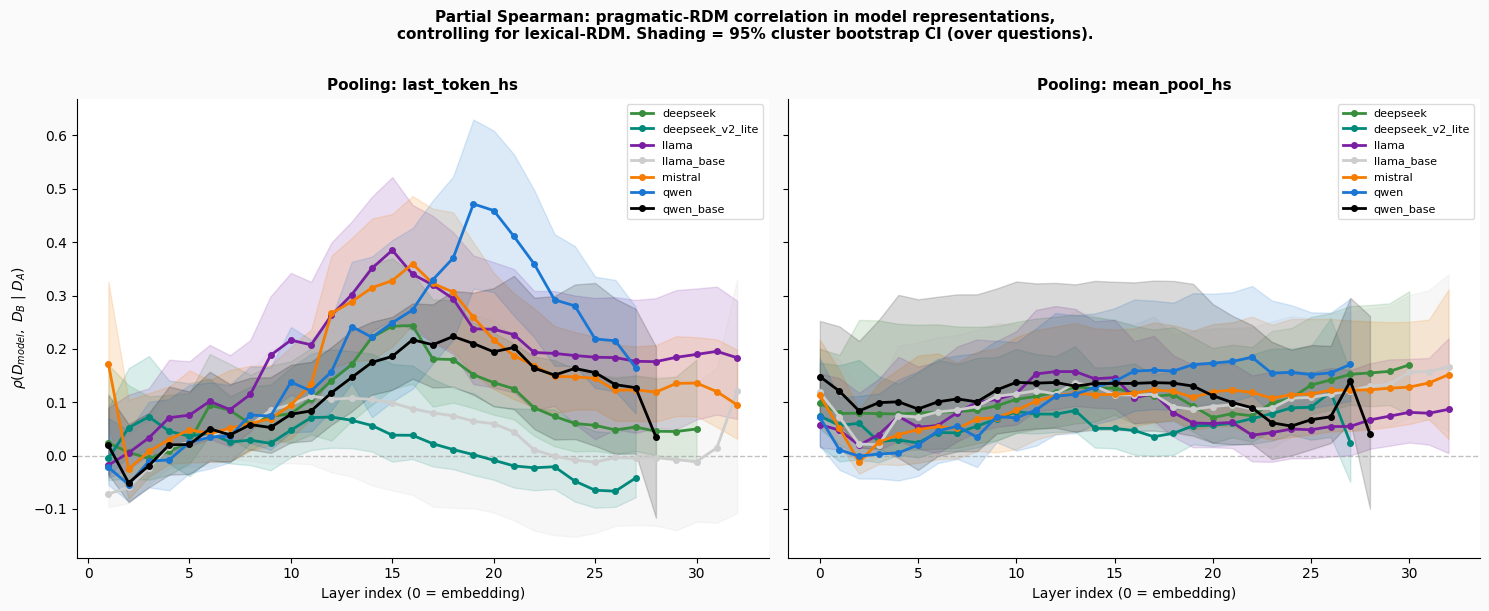

Trajectory plot -> data\rdm_outputs\rdm_trajectory.png


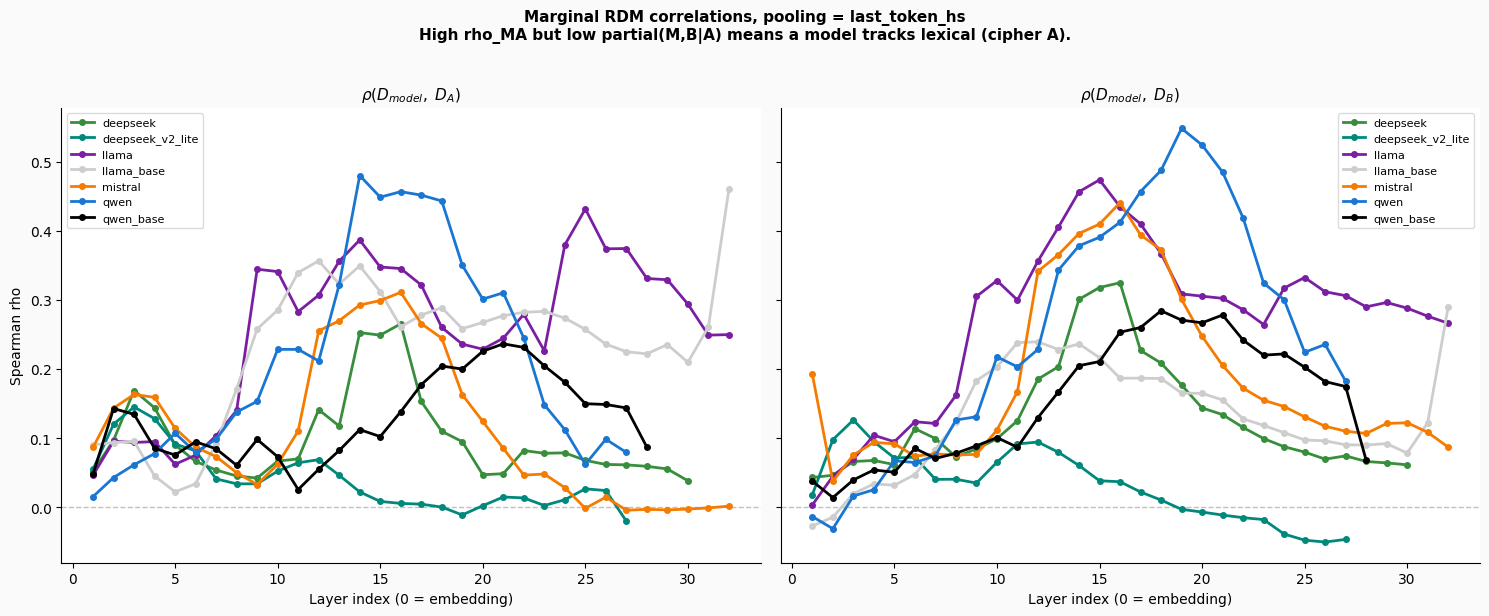

Marginals plot  -> data\rdm_outputs\rdm_marginals.png


In [11]:
import matplotlib.pyplot as plt

def plot_trajectory(results, out_path):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    fig.patch.set_facecolor('#FAFAFA')
    for ax, pooling in zip(axes, POOLING_VARIANTS):
        ax.set_facecolor('white')
        ax.spines[['top', 'right']].set_visible(False)
        ax.axhline(0, color='#999', lw=1, ls='--', alpha=0.6)
        sub = results[results['pooling'] == pooling]
        for model in sorted(sub['model'].unique()):
            d = sub[(sub['model'] == model) & (~sub['skipped'])].sort_values('layer')
            if d.empty: continue
            color = MODEL_COLORS.get(model, '#666')
            ax.plot(d['layer'], d['point'], color=color, lw=2,
                    marker='o', markersize=4, label=model)
            ax.fill_between(d['layer'], d['ci_lo'], d['ci_hi'],
                            color=color, alpha=0.15)
        ax.set_xlabel('Layer index (0 = embedding)', fontsize=10)
        ax.set_title(f'Pooling: {pooling}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8, loc='best', framealpha=0.7)
    axes[0].set_ylabel(r'$\rho(D_{model},\ D_{B}\ |\ D_{A})$', fontsize=10)
    fig.suptitle(
        'Partial Spearman: pragmatic-RDM correlation in model representations,\n'
        'controlling for lexical-RDM. Shading = 95% cluster bootstrap CI (over questions).',
        fontsize=11, fontweight='bold', y=1.01,
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Trajectory plot -> {out_path}')


def plot_marginals(results, out_path, pooling='last_token_hs'):
    sub = results[(results['pooling'] == pooling) & (~results['skipped'])]
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    fig.patch.set_facecolor('#FAFAFA')
    labels = [r'$\rho(D_{model},\ D_A)$', r'$\rho(D_{model},\ D_B)$']
    for ax, col, lbl in zip(axes, ['rho_ma', 'rho_mb'], labels):
        ax.set_facecolor('white')
        ax.spines[['top', 'right']].set_visible(False)
        ax.axhline(0, color='#999', lw=1, ls='--', alpha=0.6)
        for model in sorted(sub['model'].unique()):
            d = sub[sub['model'] == model].sort_values('layer')
            color = MODEL_COLORS.get(model, '#666')
            ax.plot(d['layer'], d[col], color=color, lw=2,
                    marker='o', markersize=4, label=model)
        ax.set_xlabel('Layer index (0 = embedding)', fontsize=10)
        ax.set_title(lbl, fontsize=11, fontweight='bold')
        ax.legend(fontsize=8, loc='best', framealpha=0.7)
    axes[0].set_ylabel('Spearman rho', fontsize=10)
    fig.suptitle(
        f'Marginal RDM correlations, pooling = {pooling}\n'
        'High rho_MA but low partial(M,B|A) means a model tracks lexical (cipher A).',
        fontsize=11, fontweight='bold', y=1.02,
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Marginals plot  -> {out_path}')

plot_trajectory(results_df, OUTPUT_DIR / 'rdm_trajectory.png')
plot_marginals(results_df, OUTPUT_DIR / 'rdm_marginals.png')

In [12]:
# Peak partial correlation per (model, pooling)
print('=' * 70)
print('SUMMARY: peak partial correlation per (model, pooling)')
print('=' * 70)
for model in sorted(results_df['model'].unique()):
    for pooling in POOLING_VARIANTS:
        d = results_df[(results_df['model'] == model) &
                       (results_df['pooling'] == pooling) &
                       (~results_df['skipped'])]
        if d.empty:
            continue
        best = d.loc[d['point'].idxmax()]
        ci_str = (f'[{best["ci_lo"]:+.3f}, {best["ci_hi"]:+.3f}]'
                  if not np.isnan(best['ci_lo']) else '[CI degenerate]')
        print(f'  {model:<20} {pooling:<14} '
              f'layer {int(best["layer"]):>3}  '
              f'partial rho = {best["point"]:+.3f}  {ci_str}')

SUMMARY: peak partial correlation per (model, pooling)
  deepseek             last_token_hs  layer  16  partial rho = +0.244  [+0.135, +0.341]
  deepseek             mean_pool_hs   layer  30  partial rho = +0.170  [+0.076, +0.308]
  deepseek_v2_lite     last_token_hs  layer   3  partial rho = +0.073  [+0.010, +0.187]
  deepseek_v2_lite     mean_pool_hs   layer  26  partial rho = +0.119  [+0.035, +0.257]
  llama                last_token_hs  layer  15  partial rho = +0.385  [+0.255, +0.522]
  llama                mean_pool_hs   layer  12  partial rho = +0.157  [+0.087, +0.280]
  llama_base           last_token_hs  layer  32  partial rho = +0.120  [-0.108, +0.330]
  llama_base           mean_pool_hs   layer  32  partial rho = +0.167  [+0.045, +0.340]
  mistral              last_token_hs  layer  16  partial rho = +0.359  [+0.244, +0.487]
  mistral              mean_pool_hs   layer  32  partial rho = +0.152  [+0.031, +0.311]
  qwen                 last_token_hs  layer  19  partial rho = +0

In [13]:
try:
    print(f"'results_df' is defined and is of type: {type(results_df)}")
    print(f"'results_df' contains {len(results_df)} rows and {len(results_df.columns)} columns.")
except NameError:
    print("'results_df' is not defined in the current scope.")

'results_df' is defined and is of type: <class 'pandas.core.frame.DataFrame'>
'results_df' contains 432 rows and 13 columns.


In [14]:
import pandas as pd
sem_ref = pd.read_csv(SCORES_PATH).dropna(subset=['Num', 'AV'])
sem_ref = sem_ref[['Num', 'SEM']].rename(columns={'Num': 'prompt_id'})
sem_ref['prompt_id'] = sem_ref['prompt_id'].astype(int)
check = pred[['prompt_id']].assign(sim_notebook=sims_a).merge(sem_ref, on='prompt_id')
diff = (check['sim_notebook'] - check['SEM']).abs()
print(f"max |notebook - SEM| = {diff.max():.6f}")
print(f"mean |notebook - SEM| = {diff.mean():.6f}")

max |notebook - SEM| = 0.000001
mean |notebook - SEM| = 0.000000


In [15]:
# === Within-condition representational geometry =========================
# Tests whether II prompts cluster differently than DI/SI in mid-stack.
# Cluster bootstrap over questions, both raw and per-dim standardised.

import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import norm

CONDITIONS  = ['direct_information', 'implicature_information', 'stochastic_information']
COND_SHORT  = {'direct_information': 'DI',
               'implicature_information': 'II',
               'stochastic_information': 'SI'}


def _cos_mat(X):
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    return np.clip(Xn @ Xn.T, -1.0, 1.0)


def _within_cond_means(cos, cond_labels):
    out = {}
    for c in CONDITIONS:
        idx = np.where(cond_labels == c)[0]
        if len(idx) < 2:
            out[c] = np.nan; continue
        sub = cos[np.ix_(idx, idx)]
        iu  = np.triu_indices(len(idx), k=1)
        out[c] = float(sub[iu].mean())
    return out

def _bootstrap_ii_contrast(features, cond_labels, qids, n_boot, seed):
    """Bootstrap CI on the II-vs-others contrast: II - (DI+SI)/2."""
    rng = np.random.default_rng(seed)
    all_qs = np.array(sorted(np.unique(qids)))
    q_to_rows = {q: np.where(qids == q)[0] for q in all_qs}

    def contrast(feats, conds):
        wc = _within_cond_means(_cos_mat(feats), conds)
        di, ii, si = wc['direct_information'], wc['implicature_information'], \
                      wc['stochastic_information']
        if any(np.isnan([di, ii, si])): return np.nan
        return ii - 0.5 * (di + si)

    point = contrast(features, cond_labels)
    boots = []
    for _ in range(n_boot):
        samp_qs   = rng.choice(all_qs, size=len(all_qs), replace=True)
        samp_rows = np.concatenate([q_to_rows[q] for q in samp_qs])
        v = contrast(features[samp_rows], cond_labels[samp_rows])
        if not np.isnan(v): boots.append(v)

    if len(boots) < 20:
        return point, np.nan, np.nan
    boots = np.array(boots)
    return (point,
            float(np.percentile(boots,  2.5)),
            float(np.percentile(boots, 97.5)))
    
def _bootstrap_within_cond(features, cond_labels, qids, n_boot, seed):
    """Cluster bootstrap with BCa intervals.

    BCa corrects for bias (median of bootstrap dist != point) and
    acceleration (skew). Required when point estimate sits outside
    naive percentile CI.
    """
    rng = np.random.default_rng(seed)
    all_qs = np.array(sorted(np.unique(qids)))
    q_to_rows = {q: np.where(qids == q)[0] for q in all_qs}

    point = _within_cond_means(_cos_mat(features), cond_labels)

    # Bootstrap distribution
    boots = {c: [] for c in CONDITIONS}
    for _ in range(n_boot):
        samp_qs   = rng.choice(all_qs, size=len(all_qs), replace=True)
        samp_rows = np.concatenate([q_to_rows[q] for q in samp_qs])
        wc = _within_cond_means(_cos_mat(features[samp_rows]),
                                cond_labels[samp_rows])
        for c in CONDITIONS:
            if not np.isnan(wc[c]): boots[c].append(wc[c])

    # Jackknife over questions for acceleration
    jack = {c: [] for c in CONDITIONS}
    for q_drop in all_qs:
        keep_rows = np.concatenate([q_to_rows[q] for q in all_qs if q != q_drop])
        wc = _within_cond_means(_cos_mat(features[keep_rows]),
                                cond_labels[keep_rows])
        for c in CONDITIONS:
            if not np.isnan(wc[c]): jack[c].append(wc[c])

    out = {}
    for c in CONDITIONS:
        b = np.array(boots[c]); j = np.array(jack[c])
        if b.size < 20 or np.isnan(point[c]):
            out[c] = (point[c], np.nan, np.nan); continue

        # Bias-correction z0
        prop_below = (b < point[c]).mean()
        prop_below = np.clip(prop_below, 1.0 / len(b), 1 - 1.0 / len(b))
        z0 = norm.ppf(prop_below)

        # Acceleration from jackknife
        j_mean = j.mean()
        num = ((j_mean - j) ** 3).sum()
        den = 6.0 * (((j_mean - j) ** 2).sum() ** 1.5)
        a = num / den if den > 0 else 0.0

        # BCa-adjusted percentiles
        z_lo, z_hi = norm.ppf(0.025), norm.ppf(0.975)
        alpha_lo = norm.cdf(z0 + (z0 + z_lo) / (1 - a * (z0 + z_lo)))
        alpha_hi = norm.cdf(z0 + (z0 + z_hi) / (1 - a * (z0 + z_hi)))
        lo = float(np.percentile(b, 100 * alpha_lo))
        hi = float(np.percentile(b, 100 * alpha_hi))
        out[c] = (point[c], lo, hi)

    return out


def _standardise(features, eps=1e-6):
    mu, sigma = features.mean(0, keepdims=True), features.std(0, keepdims=True)
    return (features - mu) / np.where(sigma < eps, 1.0, sigma)


# === Main loop â€” same alignment pattern as analyze_model ================
records = []
contrast_records = []
for npz_path in npz_files:
    label     = npz_path.stem.replace('hidden_states_', '')
    meta_path = DATA_DIR / f'hidden_states_meta_{label}.csv'
    if not meta_path.exists():
        print(f'  Skipping {label}: missing metadata CSV'); continue

    npz  = np.load(npz_path)
    meta = pd.read_csv(meta_path)

    # Align meta -> pred by prompt_id (same as analyze_model)
    valid_pids   = pred['prompt_id'].values
    meta_idx_map = {int(pid): i for i, pid in enumerate(meta['prompt_id'].values)}
    keep_npz, keep_pred = [], []
    for i, pid in enumerate(valid_pids):
        if int(pid) in meta_idx_map:
            keep_npz.append(meta_idx_map[int(pid)]); keep_pred.append(i)
    keep_npz, keep_pred = np.array(keep_npz), np.array(keep_pred)

    cond_labels  = pred['condition'].values[keep_pred]
    question_ids = pred['question_id'].values[keep_pred]
    nan_mask     = npz['nan_mask'][keep_npz]
    n_prompts    = len(keep_npz)

    print(f'\nModel: {label}  (n={n_prompts})')
    for pooling in POOLING_VARIANTS:
        feats = npz[pooling][keep_npz]   # (n_prompts, n_layers, hidden_dim)
        n_layers = feats.shape[1]
        for layer in tqdm(range(n_layers),
                          desc=f'  {label}/{pooling}', leave=False):
            if int(nan_mask[:, layer].sum()) > 0.5 * n_prompts:
                continue
            X_raw = feats[:, layer, :].astype(np.float32)
            for std_flag, X in [(False, X_raw), (True, _standardise(X_raw))]:
                wc = _bootstrap_within_cond(X, cond_labels, question_ids,
                                            N_BOOT, RANDOM_SEED)
                for c, (pt, lo, hi) in wc.items():
                    records.append(dict(
                        model=label, pooling=pooling, layer=layer,
                        standardised=std_flag, condition=COND_SHORT[c],
                        mean_cos=pt, ci_lo=lo, ci_hi=hi))
                    pt_c, lo_c, hi_c = _bootstrap_ii_contrast(
                    X, cond_labels, question_ids, N_BOOT, RANDOM_SEED)
                contrast_records.append(dict(
                    model=label, pooling=pooling, layer=layer,
                    standardised=std_flag,
                    contrast=pt_c, ci_lo=lo_c, ci_hi=hi_c))

wc_df = pd.DataFrame(records)
wc_df.to_csv(OUTPUT_DIR / 'within_condition_geometry.csv', index=False)
contrast_df = pd.DataFrame(contrast_records)
contrast_df.to_csv(OUTPUT_DIR / 'within_condition_contrast.csv', index=False)
print(f'Written -> {OUTPUT_DIR / "within_condition_contrast.csv"}')
print(f'\nWritten -> {OUTPUT_DIR / "within_condition_geometry.csv"}')

# === Derive peak layers empirically from standardised partial-correlation
# trajectories (last_token_hs). This dict is shared with the PCA cell that
# follows. Including base models (which were skipped by the previous
# hardcoded version) and any other model present in results_std_df.
#
# Caveat: argmax-then-analyze induces mild selection bias. Downstream
# results at the picked layer should be read as descriptive rather than
# as hypothesis tests at that specific depth.
peak_src = results_std_df[(results_std_df['pooling'] == 'last_token_hs')
                          & (~results_std_df['skipped'])
                          & (results_std_df['point'].notna())]
peak_layers = {}
peak_strength = {}  # store CI alongside layer index for the summary print
for m in sorted(peak_src['model'].unique()):
    d = peak_src[peak_src['model'] == m]
    if d.empty:
        continue
    best = d.loc[d['point'].idxmax()]
    peak_layers[m]   = int(best['layer'])
    peak_strength[m] = (float(best['point']),
                        float(best['ci_lo']) if not np.isnan(best['ci_lo']) else None,
                        float(best['ci_hi']) if not np.isnan(best['ci_hi']) else None)

# Partial-correlation strength at each model's peak layer
print(f"\n{'model':<20} {'L*':>3}  partial rho [95% CI]            CI>0?")
for m, L in peak_layers.items():
    pt, lo, hi = peak_strength[m]
    if lo is None:
        ci_str, excl_zero = '[CI degenerate]', 'no'
    else:
        ci_str = f'[{lo:+.3f}, {hi:+.3f}]'
        excl_zero = 'YES' if lo > 0 else 'no'
    print(f"  {m:<18} {L:>3}  {pt:+.3f} {ci_str:>22}  {excl_zero}")

# === II contrast at each model's peak layer =============================
print(f"\n{'model':<20} {'L*':>3}  {'II - (DI+SI)/2':>26}  CI excludes 0?")
for m, L in peak_layers.items():
    sub = contrast_df[(contrast_df.model == m) 
                      & (contrast_df.pooling == 'last_token_hs')
                      & (contrast_df.standardised) 
                      & (contrast_df.layer == L)]
    if sub.empty: continue
    r = sub.iloc[0]
    excl = "YES" if r.ci_hi < 0 else "no"
    print(f"  {m:<18} {L:>3}  {r.contrast:+.3f} [{r.ci_lo:+.3f}, {r.ci_hi:+.3f}]  {excl}")


Model: deepseek  (n=45)



Model: deepseek_v2_lite  (n=45)



Model: llama  (n=45)



Model: llama_base  (n=45)



Model: mistral  (n=45)



Model: qwen  (n=45)



Model: qwen_base  (n=45)


Written -> data\rdm_outputs\within_condition_contrast.csv

Written -> data\rdm_outputs\within_condition_geometry.csv

model                 L*  partial rho [95% CI]            CI>0?
  deepseek            15  +0.289       [+0.138, +0.370]  YES
  deepseek_v2_lite    12  +0.179       [+0.074, +0.276]  YES
  llama               15  +0.400       [+0.251, +0.516]  YES
  llama_base          32  +0.197       [-0.051, +0.404]  no
  mistral             16  +0.404       [+0.257, +0.477]  YES
  qwen                19  +0.489       [+0.300, +0.637]  YES
  qwen_base           16  +0.300       [+0.162, +0.388]  YES

model                 L*              II - (DI+SI)/2  CI excludes 0?
  deepseek            15  -0.105 [-0.160, -0.044]  YES
  deepseek_v2_lite    12  -0.106 [-0.156, -0.038]  YES
  llama               15  -0.183 [-0.261, -0.084]  YES
  llama_base          32  -0.130 [-0.223, -0.013]  YES
  mistral             16  -0.163 [-0.227, -0.076]  YES
  qwen                19  -0.288 [-0.335, -0.19

In [16]:
# === II dispersion structure: low-rank vs high-dimensional? ==============
# For each model, PCA the II prompts at the peak layer and check whether
# variance concentrates in a few components (structured dispersion) or
# spreads broadly (unstructured noise).
#
# Diagnostics per model:
#   - explained variance of PC1, PC1+2, PC1-3
#   - participation ratio: PR = (Î£Î»_i)Â² / Î£(Î»_iÂ²)
#       PR â‰ˆ 1 when one PC dominates, PR â‰ˆ k when k PCs share variance equally
#   - same metrics for DI and SI as a baseline (II should look different
#     from DI/SI under interpretation b, similar to them under (a))

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

CONDITIONS = ['direct_information', 'implicature_information', 'stochastic_information']
COND_SHORT = {'direct_information': 'DI',
              'implicature_information': 'II',
              'stochastic_information': 'SI'}


def _participation_ratio(eigenvalues):
    """PR = (Î£Î»)Â² / Î£(Î»Â²). Effective dimensionality of the variance."""
    ev = np.asarray(eigenvalues, dtype=float)
    ev = ev[ev > 0]
    if ev.size == 0: return np.nan
    return float(ev.sum() ** 2 / (ev ** 2).sum())


def _pca_diag(X):
    """X: (n, D) for one condition. Returns dict of dispersion diagnostics."""
    if X.shape[0] < 3:
        return dict(n=X.shape[0], pc1=np.nan, pc12=np.nan, pc123=np.nan,
                    PR=np.nan, total_var=np.nan)
    # Standardise per-dim (same as the rest of the analysis pipeline)
    Xc = (X - X.mean(0)) / (X.std(0) + 1e-8)
    n_comp = min(X.shape[0] - 1, X.shape[1])
    pca = PCA(n_components=n_comp).fit(Xc)
    evr = pca.explained_variance_ratio_
    return dict(
        n=X.shape[0],
        pc1=float(evr[0]),
        pc12=float(evr[:2].sum()),
        pc123=float(evr[:3].sum()),
        PR=_participation_ratio(pca.explained_variance_),
        total_var=float(np.sum(pca.explained_variance_)),
    )


# === Main loop ============================================================
records = []
for npz_path in npz_files:
    label     = npz_path.stem.replace('hidden_states_', '')
    meta_path = DATA_DIR / f'hidden_states_meta_{label}.csv'
    if not meta_path.exists() or label not in peak_layers:
        continue
    L = peak_layers[label]

    npz  = np.load(npz_path)
    meta = pd.read_csv(meta_path)

    # Same alignment as earlier cells
    valid_pids   = pred['prompt_id'].values
    meta_idx_map = {int(pid): i for i, pid in enumerate(meta['prompt_id'].values)}
    keep_npz, keep_pred = [], []
    for i, pid in enumerate(valid_pids):
        if int(pid) in meta_idx_map:
            keep_npz.append(meta_idx_map[int(pid)]); keep_pred.append(i)
    keep_npz, keep_pred = np.array(keep_npz), np.array(keep_pred)
    cond_labels = pred['condition'].values[keep_pred]

    feats = npz['last_token_hs'][keep_npz][:, L, :].astype(np.float32)

    for c in CONDITIONS:
        idx = np.where(cond_labels == c)[0]
        diag = _pca_diag(feats[idx])
        records.append(dict(model=label, layer=L, condition=COND_SHORT[c], **diag))

pca_df = pd.DataFrame(records)
pca_df.to_csv(OUTPUT_DIR / 'ii_dispersion_pca.csv', index=False)

# === Summary table ========================================================
print(f"\n{'model':<20} {'L':>3} {'cond':>4}  {'n':>3}  "
      f"{'PC1%':>6}  {'PC1-2%':>7}  {'PC1-3%':>7}  {'PR':>5}")
for m in sorted(pca_df['model'].unique()):
    for c in ['DI', 'II', 'SI']:
        r = pca_df[(pca_df.model == m) & (pca_df.condition == c)].iloc[0]
        print(f"  {m:<18} {int(r.layer):>3} {c:>4}  {int(r.n):>3}  "
              f"{100*r.pc1:>5.1f}  {100*r.pc12:>6.1f}  "
              f"{100*r.pc123:>6.1f}  {r.PR:>5.2f}")

# === Interpretation hint ==================================================
print(f"\n{'model':<20}  II-vs-DI/SI structural signature")
print("=" * 70)
for m in sorted(pca_df['model'].unique()):
    sub = pca_df[pca_df.model == m].set_index('condition')
    if not all(c in sub.index for c in ['DI', 'II', 'SI']): continue
    pr_ii  = sub.loc['II', 'PR']
    pr_avg = 0.5 * (sub.loc['DI', 'PR'] + sub.loc['SI', 'PR'])
    pc1_ii  = sub.loc['II', 'pc1']
    pc1_avg = 0.5 * (sub.loc['DI', 'pc1'] + sub.loc['SI', 'pc1'])

    if pr_ii > pr_avg + 0.5 and pc1_ii < pc1_avg - 0.05:
        verdict = "(a) high-dim noise â€” II is broadly dispersed"
    elif pr_ii < pr_avg and pc1_ii > pc1_avg + 0.05:
        verdict = "(b) low-rank structure â€” II varies along few axes"
    else:
        verdict = "ambiguous â€” II dispersion is not clearly low- or high-rank"
    print(f"  {m:<18}  PR(II)={pr_ii:.2f} vs PR(DI,SI)={pr_avg:.2f}  "
          f"PC1(II)={100*pc1_ii:.1f}% vs PC1(DI,SI)={100*pc1_avg:.1f}%")
    print(f"  {'':<18}  â†’ {verdict}")


model                  L cond    n    PC1%   PC1-2%   PC1-3%     PR
  deepseek            15   DI   15   18.6    32.5    43.9   9.85
  deepseek            15   II   15   13.9    25.1    35.6  11.70
  deepseek            15   SI   15   13.9    26.2    36.8  11.50
  deepseek_v2_lite    12   DI   15   22.2    37.9    50.5   8.57
  deepseek_v2_lite    12   II   15   22.7    35.3    45.2   9.20
  deepseek_v2_lite    12   SI   15   19.7    33.1    44.7   9.69
  llama               15   DI   15   23.7    38.9    52.1   8.12
  llama               15   II   15   14.2    27.2    38.6  11.15
  llama               15   SI   15   17.0    33.2    43.8   9.70
  llama_base          32   DI   15   26.5    39.3    50.3   7.98
  llama_base          32   II   15   19.1    34.9    47.1   9.42
  llama_base          32   SI   15   18.6    33.1    45.8   9.51
  mistral             16   DI   15   19.7    36.2    48.7   8.93
  mistral             16   II   15   15.2    28.0    39.2  10.89
  mistral            